# Code to AI — Week 6, Day 3: Practice Lab
**Netflix Project — Guided Build**

---

This is the scaffolded version of today's project. The cleaning steps are written out for
you with short gaps to fill; the **insights are entirely yours to write**.

Work through it, then use what you learn here to write your own version from scratch in
the assignment.

> **Working in Google Colab?**
> Colab does not see the files on your computer. Run the cell below **first** to upload
> `netflix_titles.csv`, then skip the `read_csv('data/...')` cell and use this one instead.
>
> If you are running locally in VS Code, ignore this and use the normal loading cell.

In [ ]:
# ONLY run this if you are on Google Colab.
# It opens a file picker - choose your netflix_titles.csv

# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv('netflix_titles.csv')
# print("Shape:", df.shape)

---
## Part A — Load and inspect

In [6]:
import pandas as pd

# The CSV lives in the data/ folder next to this notebook
df = pd.read_csv('data/netflix_titles.csv')

print("Loaded successfully!")
print("Shape:", df.shape)

Loaded successfully!
Shape: (8612, 12)


### Task A1

Print the shape, then `.head()`, then `.info()`.

In [9]:
# Your code here
df.shape


(8612, 12)

In [10]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s8365,TV Show,Lost Kingdom,NaN,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,"June 16, 2020",2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.
1,s5294,TV Show,Lost Summer,NaN,"Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali",United States,"November 14, 2009",2007,TV-Y,1 Season,Anime Series,A sweeping story about revenge.
2,s6931,Movie,Frozen Empire II,Grace Hassan,"Omar Kumar, Fatima Khan, Chen Ali, Liam Khan",United States,"January 5, 2008",2003,NR,97 min,Horror Movies,A sweeping story about survival.
3,s7760,Movie,Endless Empire Forever,Yuki Sato,"Maria Khan, Fatima Garcia, Chen Tanaka",India,"September 15, 2014",2011,R,102 min,"Documentaries, International Movies",A hilarious story about family.
4,s3313,TV Show,Burning Dream,NaN,"Raj Wilson, Elena Wang, John Brown, Chen Wang,...",India,"April 10, 2008",2003,TV-Y7,1 Season,Docuseries,A sweeping story about ambition.


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8612 entries, 0 to 8611
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8612 non-null   str  
 1   type          8612 non-null   str  
 2   title         8612 non-null   str  
 3   director      6214 non-null   str  
 4   cast          7840 non-null   str  
 5   country       7835 non-null   str  
 6   date_added    8601 non-null   str  
 7   release_year  8612 non-null   int64
 8   rating        8608 non-null   str  
 9   duration      8609 non-null   str  
 10  listed_in     8612 non-null   str  
 11  description   8612 non-null   str  
dtypes: int64(1), str(11)
memory usage: 807.5 KB


### Task A2 — Missing-value report

Build the `report` DataFrame with `missing_count` and `missing_percent`,
showing only columns with missing data.

In [12]:
# Your code here
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})
report = report[report['missing_count'] > 0]
report = report.sort_values('missing_percent', ascending=False)

report


,missing_count,missing_percent
director,2398,27.8
cast,772,9.0
country,777,9.0
date_added,11,0.1
rating,4,0.0
duration,3,0.0


In [13]:
print("Total missing values:", df.isnull().sum().sum())
print("Total rows:", len(df))

Total missing values: 3965
Total rows: 8612


<details>
<summary>Hint</summary>

```python
report = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': (df.isnull().mean() * 100).round(1)
})
report = report[report['missing_count'] > 0].sort_values('missing_percent', ascending=False)
```
</details>

---
## Part B — Clean (scaffolded)

### Task B1 — Working copy

In [14]:
clean = df.copy()
print("Copy made:", len(clean), "rows")

Copy made: 8612 rows


### Task B2 — Duplicates

Print the duplicate count, remove them, print before/after row counts.

In [17]:
# Your code here
print("Duplicate rows found:", clean.duplicated().sum())
clean[clean.duplicated(keep=False)]
rows_before = len(clean)
clean = clean.drop_duplicates()
rows_after = len(clean)

print("Before:", rows_before)
print("After: ", rows_after)
print("Removed:", rows_before - rows_after, "duplicate rows")

Duplicate rows found: 12
Before: 8612
After:  8600
Removed: 12 duplicate rows


### Task B3 — Strip whitespace

Loop over the text columns and apply `.str.strip()` to each.

In [19]:
text_columns = ['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']

# Your code here - loop over text_columns
for i in text_columns: 
    clean[i]  = clean[i].str.strip()
text_columns


['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in']

<details>
<summary>Hint</summary>

```python
for col in text_columns:
    clean[col] = clean[col].str.strip()
```
</details>

### Task B4 — Fill with "Unknown"

Fill `director`, `cast` and `country` with `'Unknown'`.

In [20]:
# Your code here
for i in ['director', 'cast', 'country']:
    print(f"{i}: {clean[i].isnull().sum()} missing before")
    clean[i] = clean[i].fillna('Unknown')
    print(f"{i}: {clean[i].isnull().sum()} missing after")
    print()


director: 2396 missing before
director: 0 missing after

cast: 771 missing before
cast: 0 missing after

country: 776 missing before
country: 0 missing after



### Task B5 — Drop the unfixable rows

Drop rows missing `date_added`, `rating` or `duration`. Print how many rows this cost,
and what percentage of the data that was.

In [21]:
# Your code here
rows_before = len(clean)

clean = clean.dropna(subset=['date_added', 'rating', 'duration'])


print("Before:", rows_before)
print("After: ", len(clean))
print("Dropped:", rows_before - len(clean), "rows")
print()
print("That is", round((rows_before - len(clean)) / rows_before * 100, 2), "% of the data - acceptable.")

Before: 8600
After:  8582
Dropped: 18 rows

That is 0.21 % of the data - acceptable.


### Task B6 — Convert the date

Convert `date_added` with `pd.to_datetime(..., format='mixed')`, then create
`year_added` from it.

In [22]:
# Your code here
clean['date_added'] = pd.to_datetime(clean['date_added'], format='mixed')

print("Type after:", clean['date_added'].dtype)
print("Example value:", clean['date_added'].iloc[0])

Type after: datetime64[us]
Example value: 2020-06-16 00:00:00


In [23]:
clean['year_added'] = clean['date_added'].dt.year
clean['month_added'] = clean['date_added'].dt.month_name()

clean[['title', 'date_added', 'year_added', 'month_added']].head()

,title,date_added,year_added,month_added
0,Lost Kingdom,2020-06-16,2020,June
1,Lost Summer,2009-11-14,2009,November
2,Frozen Empire II,2008-01-05,2008,January
3,Endless Empire Forever,2014-09-15,2014,September
4,Burning Dream,2008-04-10,2008,April


### Task B7 — Split the duration

Split `duration` into `duration_number` (numeric) and `duration_unit`.

In [24]:

# Your code here
clean['duration'].head(3).tolist()

['1 Season', '1 Season', '97 min']

<details>
<summary>Hint</summary>

```python
parts = clean['duration'].str.split(' ', expand=True)
clean['duration_number'] = pd.to_numeric(parts[0])
clean['duration_unit'] = parts[1]
```
</details>

In [25]:
parts = clean['duration'].str.split(' ', expand=True)
clean['duration_number'] = pd.to_numeric(parts[0])
clean['duration_unit'] = parts[1]

In [26]:
print(clean['duration_unit'].value_counts())

duration_unit
min        6026
Seasons    1627
Season      929
Name: count, dtype: int64


### Task B8 — Verify

Print the total missing values remaining. It should be 0.

In [27]:
# Your code here
print("Missing values remaining:")
print(clean.isnull().sum())
print()
print("TOTAL missing:", clean.isnull().sum().sum())

Missing values remaining:
show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added         0
release_year       0
rating             0
duration           0
listed_in          0
description        0
year_added         0
month_added        0
duration_number    0
duration_unit      0
dtype: int64

TOTAL missing: 0


---
## Part C — Insights (all yours)

No hints from here on. This is the part that goes in your portfolio.

### Task C1 — Movies vs TV Shows

Count them, and also show the percentages.

In [28]:
# Your code here
type_counts = clean['type'].value_counts()
print(type_counts)
print()

type_percent = (clean['type'].value_counts(normalize=True) * 100).round(1)
print("As percentages:")
print(type_percent)

type
Movie      6026
TV Show    2556
Name: count, dtype: int64

As percentages:
type
Movie      70.2
TV Show    29.8
Name: proportion, dtype: float64


### Task C2 — Top 10 countries

In [29]:
# Your code here
top_countries = clean['country'].value_counts().head(10)
print(top_countries)

country
United States     2657
India             1322
Unknown            776
United Kingdom     697
Canada             440
Japan              355
France             334
South Korea        315
Spain              265
Mexico             258
Name: count, dtype: int64


### Task C3 — Titles added per year

Sorted by year, not by count.

In [30]:
# Your code here
per_year = clean['year_added'].value_counts().sort_index()
print(per_year)

year_added
2008    1474
2009     320
2010     376
2011     437
2012     439
2013     484
2014     445
2015     470
2016     464
2017     475
2018     445
2019     424
2020     404
2021    1925
Name: count, dtype: int64


### Task C4 — Movie duration statistics

Filter to movies only, then print the average, median, shortest and longest duration.

**Careful:** do not average across both types. Minutes and seasons are different units.

In [31]:
# Your code here
movies = clean[clean['type'] == 'Movie']

print("Number of movies:", len(movies))
print("Average duration:", round(movies['duration_number'].mean(), 1), "minutes")
print("Median duration: ", movies['duration_number'].median(), "minutes")
print("Shortest:", movies['duration_number'].min(), "minutes")
print("Longest: ", movies['duration_number'].max(), "minutes")

Number of movies: 6026
Average duration: 98.7 minutes
Median duration:  98.0 minutes
Shortest: 45 minutes
Longest:  183 minutes


### Task C5 — TV show seasons

Now filter to TV shows and find the most common number of seasons.

In [41]:
tv_shows = clean[clean['type'] == 'TV Show']
print(tv_shows['duration'].value_counts().head())

most_common = tv_shows['duration'].value_counts().max()
print("Most common no  of seasons :", most_common)



duration
1 Season     929
2 Seasons    443
8 Seasons    254
6 Seasons    252
3 Seasons    231
Name: count, dtype: int64
Most common no  of seasons : 929


### Task C6 — Your own question

Ask one question of this dataset that nobody told you to ask. Write it here, then
answer it with code below.

**My question:*What is the most common movie rating?*

In [44]:
# Your code here
print(clean['rating'].value_counts().head(10))

rating
TV-14    1184
TV-G     1120
TV-MA    1118
TV-PG    1084
NR        658
R         658
G         657
PG        643
PG-13     642
TV-Y      422
Name: count, dtype: int64


---
## Part D — Chart and save

### Task D1 — One bar chart

Chart the titles added per year with a single `.plot(kind='bar')` call.
Give it a title and axis labels.

<Axes: title={'center': 'Netflix Titles Added Per Year'}, xlabel='Year', ylabel='Number of Movies and TV Shows'>

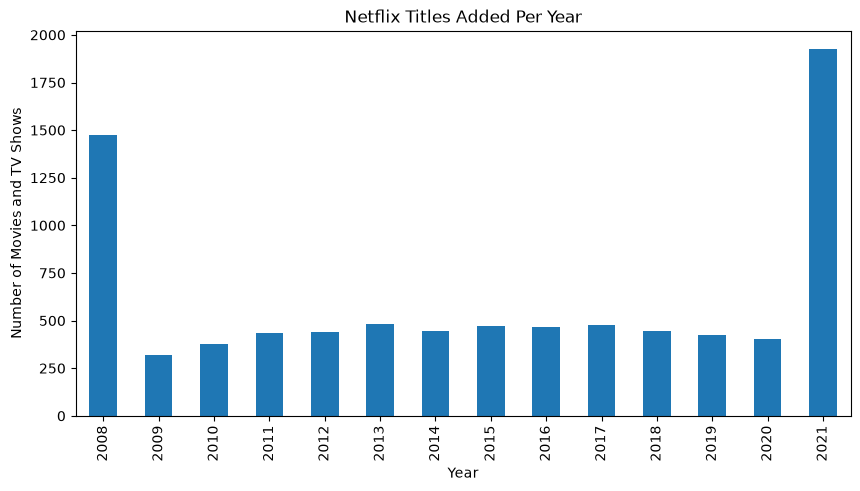

In [45]:
# Your code here
per_year.plot(
    kind='bar',
    title='Netflix Titles Added Per Year',
    xlabel='Year',
    ylabel='Number of Movies and TV Shows',
    figsize=(10, 5)
)

### Task D2 — Save the cleaned CSV

Save as `netflix_clean.csv` with `index=False`, then read it back to confirm it worked.

In [46]:
# Your code here
clean.to_csv('netflix_clean.csv', index=False)

print("Saved netflix_clean.csv")
print("Rows:", len(clean), "| Columns:", len(clean.columns))

Saved netflix_clean.csv
Rows: 8582 | Columns: 16


In [47]:

check = pd.read_csv('netflix_clean.csv')
print("Reloaded shape:", check.shape)
check.head(3)

Reloaded shape: (8582, 16)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_number,duration_unit
0,s8365,TV Show,Lost Kingdom,Unknown,"Diego Sato, Yuki Wang, Raj Tanaka, Liam Brown,...",India,2020-06-16,2019,TV-MA,1 Season,"British TV Shows, TV Dramas",A gripping story about love.,2020,June,1,Season
1,s5294,TV Show,Lost Summer,Unknown,"Diego Kumar, Diego Tanaka, Raj Garcia, Maria Ali",United States,2009-11-14,2007,TV-Y,1 Season,Anime Series,A sweeping story about revenge.,2009,November,1,Season
2,s6931,Movie,Frozen Empire II,Grace Hassan,"Omar Kumar, Fatima Khan, Chen Ali, Liam Khan",United States,2008-01-05,2003,NR,97 min,Horror Movies,A sweeping story about survival.,2008,January,97,min


---
## Done!

You now have a working cleaning pipeline and your own insights. Take this into the
assignment and write it from scratch — that is where it really sticks. 💪